In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# 1. SETUP PROJECT PATHS
project_dir = '/content/drive/MyDrive/Fake Currency detection'
data_dir = '/content/drive/MyDrive/real_fake dataset'

print(f'✅ Project Dir: {project_dir}')
print(f'✅ Data Dir:    {data_dir}')

# Create subfolders for outputs if missing
os.makedirs(f'{project_dir}/models', exist_ok=True)
os.makedirs(f'{project_dir}/results', exist_ok=True)
os.makedirs(f'{project_dir}/app', exist_ok=True)

✅ Project Dir: /content/drive/MyDrive/Fake Currency detection
✅ Data Dir:    /content/drive/MyDrive/real_fake dataset


In [ ]:
# 2. GENERATORS
classes = sorted(['200_fake', '200_real', '500_fake', '500_real'])
print(f'Classes: {classes}')

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=15, width_shift_range=0.1,
    height_shift_range=0.1, brightness_range=[0.85,1.15], zoom_range=0.1
)

train_gen = train_datagen.flow_from_directory(
    f'{data_dir}/train', target_size=(224,224), batch_size=32,
    class_mode='categorical', classes=classes, shuffle=True
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    f'{data_dir}/val', target_size=(224,224), batch_size=32,
    class_mode='categorical', classes=classes
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    f'{data_dir}/test', target_size=(224,224), batch_size=32,
    class_mode='categorical', classes=classes, shuffle=False # Important for Confusion Matrix
)

Classes: ['200_fake', '200_real', '500_fake', '500_real']
Found 1834 images belonging to 4 classes.
Found 229 images belonging to 4 classes.
Found 231 images belonging to 4 classes.


In [ ]:
# 3. BASE TRAINING
print('\n🚀 Starting Base Training...')
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

model = tf.keras.Sequential([
    base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
class_weight = {0:1.35, 1:1.02, 2:0.75, 3:0.88}

history = model.fit(
    train_gen, epochs=20, validation_data=val_gen,
    class_weight=class_weight,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)]
)


🚀 Starting Base Training...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 805s 13s/step - accuracy: 0.5773 - loss: 1.0301 - val_accuracy: 0.8341 - val_loss: 0.4104
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8152 - loss: 0.4112 - val_accuracy: 0.8603 - val_loss: 0.3271
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8369 - loss: 0.3370 - val_accuracy: 0.8515 - val_loss: 0.3343
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8750 - loss: 0.2810 - val_accuracy: 0.8908 - val_loss: 0.2545
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8785 - loss: 0.2739 - val_accuracy: 0.8908 - val_loss: 0.2449
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9019 - loss: 0.2256 - val_accuracy: 0.8734 - val_loss: 0.2616
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9189 - loss: 0.1974 - val_accuracy: 0.8908 - val_loss: 0.2234
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9020 - loss: 0.2132 - val_accuracy: 0.8777 - val_los

In [ ]:
# Save Base Model
model.save(f'{project_dir}/models/fake_detector_base.h5')
base_acc = model.evaluate(test_gen, verbose=0)[1]
print(f'🏆 Base Model Saved! Test Acc: {base_acc:.1%}')

🏆 Base Model Saved! Test Acc: 93.9%


In [ ]:
print('\n🔄 Starting Fine-Tuning...')

base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False

for layer in base.layers[-20:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

optimizer = tf.keras.optimizers.Adam(1e-5)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

fine_history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=[early_stop, lr_callback]
)

model.save(f'{project_dir}/models/fake_detector_fine_tuned.h5')
fine_acc = model.evaluate(test_gen, verbose=0)[1]
print(f'🎯 Fine-tuned Model Saved! Test Acc: {fine_acc:.1%}')



🔄 Starting Fine-Tuning...
Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - accuracy: 0.7894 - loss: 0.4633 - val_accuracy: 0.9214 - val_loss: 0.2051
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.8493 - loss: 0.3356 - val_accuracy: 0.9170 - val_loss: 0.2164
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 193s 3s/step - accuracy: 0.8676 - loss: 0.2673 - val_accuracy: 0.9170 - val_loss: 0.2196
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.8895 - loss: 0.2339 - val_accuracy: 0.9214 - val_loss: 0.2298
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.8987 - loss: 0.2269 - val_accuracy: 0.9170 - val_loss: 0.2339
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.9144 - loss: 0.1942 - val_accuracy: 0.9127 - val_loss: 0.2383


In [ ]:
# Save Final Model
model.save(f'{project_dir}/models/fake_detector_final.h5')
print(f'✅ Final Model Saved to {project_dir}/models/')

✅ Final Model Saved to /content/drive/MyDrive/Fake Currency detection/models/


In [ ]:
# 5. METRICS & PLOTS
test_gen.reset()
y_pred = np.argmax(model.predict(test_gen, verbose=0), axis=1)
y_true = test_gen.classes

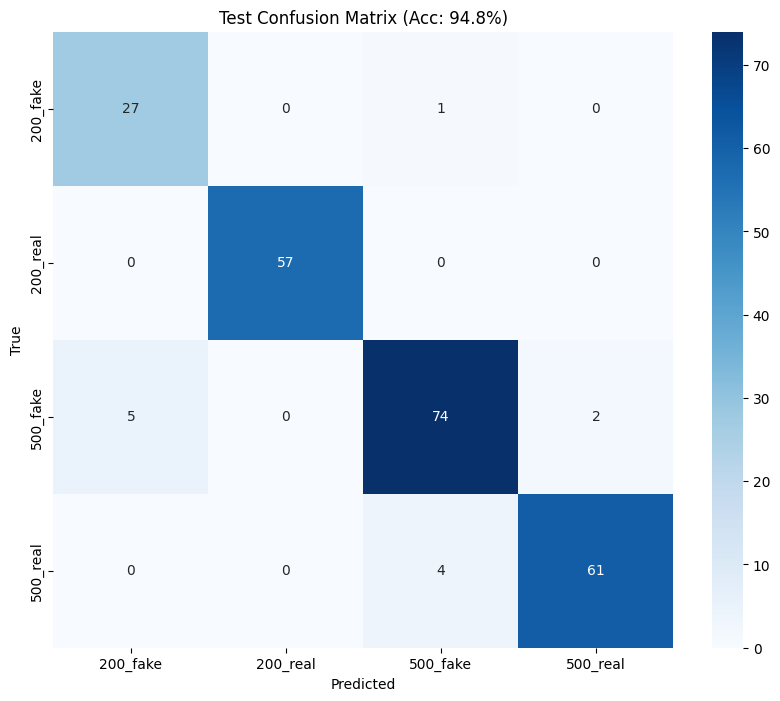

In [ ]:
# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title(f'Test Confusion Matrix (Acc: {np.mean(y_pred==y_true):.1%})')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.savefig(f'{project_dir}/results/confusion_matrix.png')
plt.show()

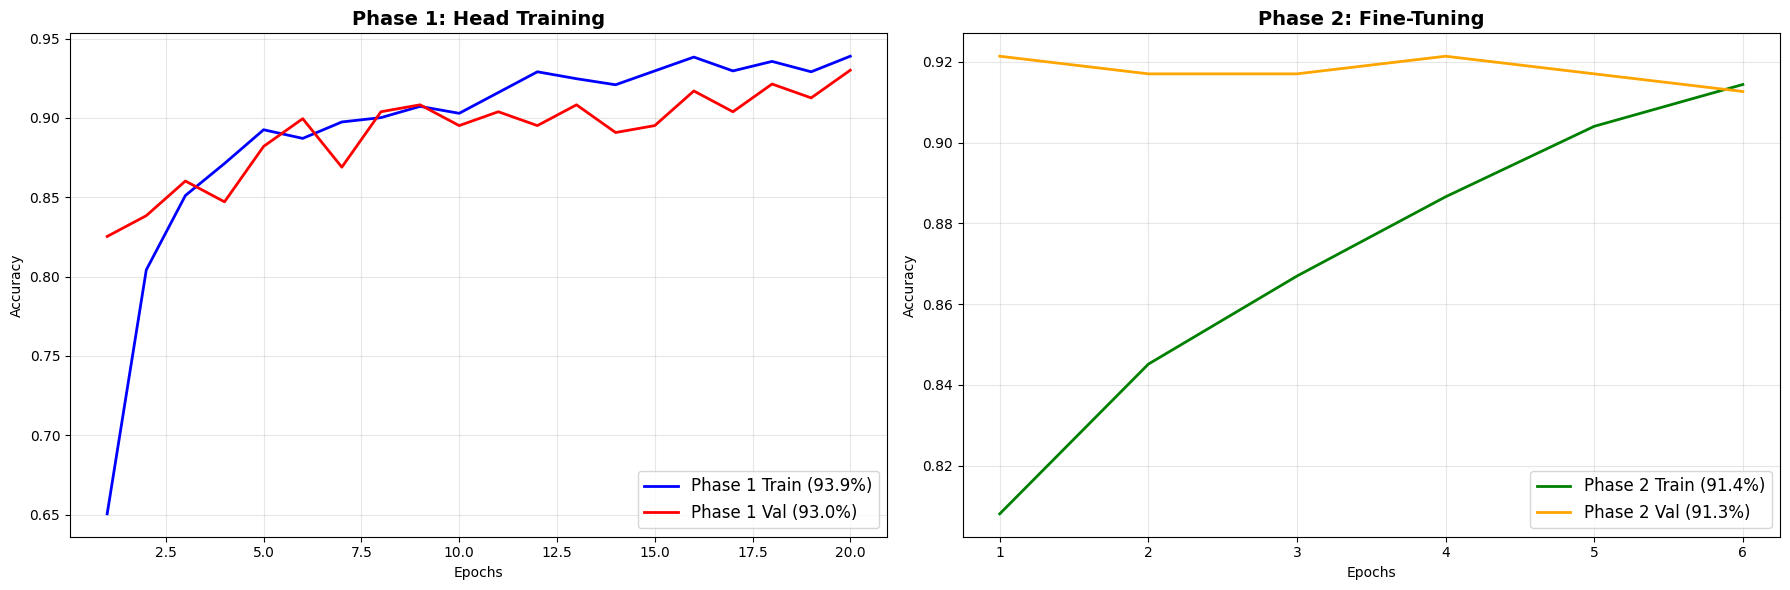

✅ Phase plot saved to: /content/drive/MyDrive/Fake Currency detection/results/training_phases_plot.png


In [ ]:
# === GENERATE PHASED TRAINING PLOT ===

# 1. Create a figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- PHASE 1: HEAD TRAINING ---
# Using data from 'history' object (Base training)
if 'history' in globals():
    p1_epochs = range(1, len(history.history['accuracy']) + 1)

    # Plot Train & Val
    ax1.plot(p1_epochs, history.history['accuracy'], 'b-', linewidth=2,
             label=f"Phase 1 Train ({history.history['accuracy'][-1]:.1%})")
    ax1.plot(p1_epochs, history.history['val_accuracy'], 'r-', linewidth=2,
             label=f"Phase 1 Val ({history.history['val_accuracy'][-1]:.1%})")

    ax1.set_title('Phase 1: Head Training', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='lower right', fontsize=12)
else:
    ax1.text(0.5, 0.5, 'Phase 1 Data Not Found', ha='center')

# --- PHASE 2: FINE-TUNING ---
# Using data from 'fine_history' object (Fine-tuning)
if 'fine_history' in globals():
    p2_epochs = range(1, len(fine_history.history['accuracy']) + 1)

    # Plot Train & Val
    ax2.plot(p2_epochs, fine_history.history['accuracy'], 'g-', linewidth=2,
             label=f"Phase 2 Train ({fine_history.history['accuracy'][-1]:.1%})")
    ax2.plot(p2_epochs, fine_history.history['val_accuracy'], 'orange', linewidth=2,
             label=f"Phase 2 Val ({fine_history.history['val_accuracy'][-1]:.1%})")

    ax2.set_title('Phase 2: Fine-Tuning', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='lower right', fontsize=12)
else:
    ax2.text(0.5, 0.5, 'Phase 2 Data Not Found', ha='center')

# Save and Show
plt.tight_layout()
save_path = f'{project_dir}/results/training_phases_plot.png'
plt.savefig(save_path, dpi=300)
plt.show()

print(f'✅ Phase plot saved to: {save_path}')


In [ ]:
# Text Report
report = classification_report(y_true, y_pred, target_names=classes, digits=3)
print(report)
with open(f'{project_dir}/results/report.txt', 'w') as f:
    f.write(report)

              precision    recall  f1-score   support

    200_fake      0.844     0.964     0.900        28
    200_real      1.000     1.000     1.000        57
    500_fake      0.937     0.914     0.925        81
    500_real      0.968     0.938     0.953        65

    accuracy                          0.948       231
   macro avg      0.937     0.954     0.945       231
weighted avg      0.950     0.948     0.948       231



In [ ]:
# 6. TFLITE CONVERSION
print('\n📱 Converting to TFLite...')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(f'{project_dir}/app/fake_detector.tflite', 'wb') as f:
    f.write(tflite_model)

print(f'✅ ALL DONE! Files in {project_dir}:')
print(os.listdir(project_dir))


📱 Converting to TFLite...
Saved artifact at '/tmp/tmpqi2eosmq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  134497101194512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134497101195280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134497101197968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134497101197584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134497101196432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134497101198160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134497101196624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134497101198736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134497101198352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134497101196240: TensorSpec(shape=(), dtype=tf.resour

🔍 Running predictions on random test images...


/tmp/ipython-input-1104927798.py:42: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1104927798.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


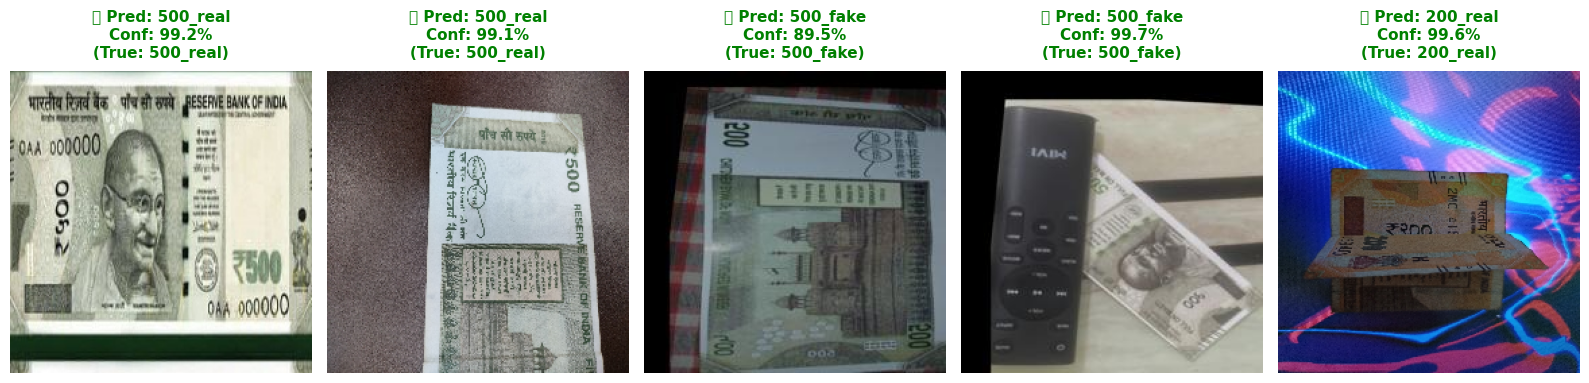

✅ Demo predictions saved to: /content/drive/MyDrive/Fake Currency detection/results/demo_predictions.png


In [ ]:
# DEMO PREDICTION: Visualize Real-Time Results
import random
from tensorflow.keras.preprocessing import image

# 1. Get test files
test_files = test_gen.filepaths
random.shuffle(test_files)
demo_files = test_files[:5]  # Pick 5 random images

plt.figure(figsize=(16, 5))

print('🔍 Running predictions on random test images...')

for i, img_path in enumerate(demo_files):
    # Load & Preprocess
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x /= 255.0  # Normalize (0-1)

    # Predict
    preds = model.predict(x, verbose=0)
    idx = np.argmax(preds)
    label = classes[idx]
    conf = preds[0][idx]

    # Truth
    true_label = os.path.basename(os.path.dirname(img_path))

    # Color: Green if correct, Red if wrong
    is_correct = (label == true_label)
    color = 'green' if is_correct else 'red'
    icon = '✅' if is_correct else '❌'

    # Plot
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{icon} Pred: {label}\nConf: {conf:.1%}\n(True: {true_label})",
              color=color, fontsize=11, fontweight='bold', pad=10)

plt.tight_layout()
save_path = f'{project_dir}/results/demo_predictions.png'
plt.savefig(save_path, dpi=300)
plt.show()

print(f'✅ Demo predictions saved to: {save_path}')